# Notebook 4: Performance Analytics
## Mutual Fund Analytics Platform - Bluestock Capstone Project

### Objective
Calculate and visualize key performance metrics for mutual funds:
- CAGR (Compound Annual Growth Rate)
- Sharpe Ratio (Risk-adjusted returns)
- Alpha & Beta (Market performance)
- Maximum Drawdown (Risk measure)
- Fund Scorecard (Overall ranking)

### Metrics Definitions
| Metric | Formula | Interpretation |
|--------|---------|----------------|
| CAGR | (NAV_end/NAV_start)^(1/n) - 1 | Annualized return |
| Sharpe Ratio | (Rp - Rf) / σp | Risk-adjusted return |
| Alpha | Actual Return - Expected Return | Manager skill |
| Beta | Cov(Rp,Rm) / Var(Rm) | Market sensitivity |
| Max Drawdown | min(NAV / running_max - 1) | Worst peak-to-trough decline |

### Visualizations Included
1. CAGR Comparison Bar Chart
2. Sharpe Ratio vs Volatility Scatter Plot
3. Sharpe Ratio Ranking Bar Chart
4. Alpha vs Beta Scatter Plot
5. Maximum Drawdown Bar Chart
6. Fund Scorecard Bar Chart
7. Performance Radar Chart
8. Performance Heatmap
9. Performance Metrics Distribution
10. Performance vs Risk Quadrant
11. Performance Summary Table

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from math import pi
import warnings

warnings.filterwarnings("ignore")

# Set visualization style
sns.set_theme(style="darkgrid")
sns.set_palette("Set1")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

print("Libraries loaded successfully")
print(f"Pandas version: {pd.__version__}")

Libraries loaded successfully
Pandas version: 3.0.3


## 1. Load Data
Load cleaned NAV data for performance calculations.

In [13]:
# Set paths
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
REPORTS_DIR = BASE_DIR / "reports" / "eda_plots"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Load cleaned NAV data
nav_df = pd.read_csv(PROCESSED_DIR / "nav_history_cleaned.csv")
nav_df["date"] = pd.to_datetime(nav_df["date"])
nav_df = nav_df.sort_values(["amfi_code", "date"])
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()

print(f"NAV Data loaded: {len(nav_df):,} rows")
print(f"Unique funds: {nav_df['amfi_code'].nunique()}")
print(f"Date range: {nav_df['date'].min().date()} to {nav_df['date'].max().date()}")

NAV Data loaded: 3,915 rows
Unique funds: 5
Date range: 2023-01-02 to 2025-12-31


## 2. CAGR Calculation
Calculate 1-year, 3-year, and 5-year CAGR for each fund.

In [14]:
def calculate_cagr(df, years):
    """Calculate CAGR for a fund over specified years."""
    if len(df) == 0:
        return 0
    start_nav = df["nav"].iloc[0]
    end_nav = df["nav"].iloc[-1]
    if start_nav > 0 and years > 0:
        return (end_nav / start_nav) ** (1 / years) - 1
    return 0


cagr_results = []
for fund in nav_df["amfi_code"].unique():
    fund_data = nav_df[nav_df["amfi_code"] == fund]
    fund_name = fund_data["scheme_name"].iloc[0]

    cagr_1y = calculate_cagr(fund_data.tail(252), 1) if len(fund_data) >= 252 else 0
    cagr_3y = calculate_cagr(fund_data.tail(756), 3) if len(fund_data) >= 756 else 0
    cagr_5y = calculate_cagr(fund_data.tail(1260), 5) if len(fund_data) >= 1260 else 0

    cagr_results.append(
        {
            "amfi_code": fund,
            "scheme_name": fund_name,
            "cagr_1y": cagr_1y * 100,
            "cagr_3y": cagr_3y * 100,
            "cagr_5y": cagr_5y * 100,
        }
    )

cagr_df = pd.DataFrame(cagr_results)
print(f"CAGR calculated for {len(cagr_df)} funds")

CAGR calculated for 5 funds


### Visualization 1: CAGR Comparison Bar Chart
This chart compares the top 10 funds by 3-year CAGR, showing 1-year, 3-year, and 5-year performance side by side.

**Key Insights:**
- Blue bars: 1-Year CAGR
- Red bars: 3-Year CAGR
- Green bars: 5-Year CAGR
- Higher bars indicate better performance

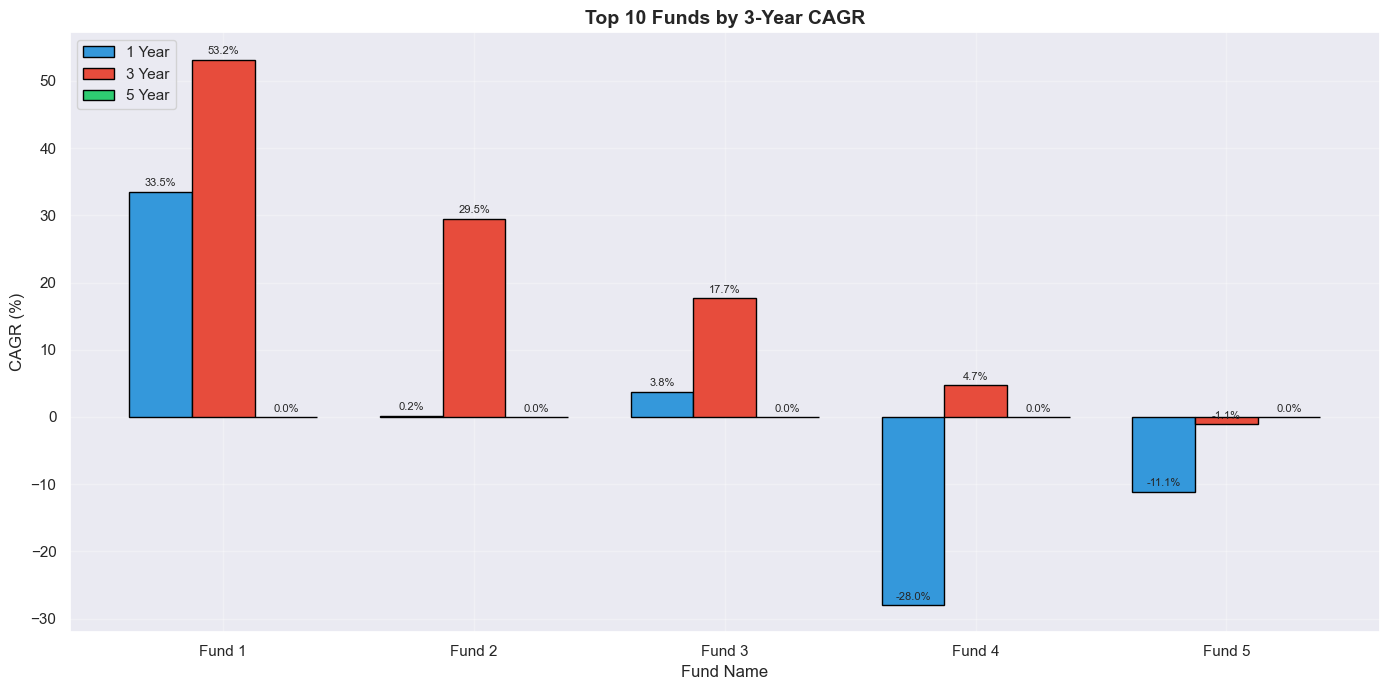


📊 CAGR Summary:
  Best 3-Year CAGR: 53.16%
  Average 3-Year CAGR: 20.80%


In [15]:
# Visualization: CAGR Comparison Bar Chart
top_10_cagr = cagr_df.nlargest(10, "cagr_3y")

plt.figure(figsize=(14, 7))
x = range(len(top_10_cagr))
width = 0.25

bars1 = plt.bar(
    [i - width for i in x],
    top_10_cagr["cagr_1y"],
    width,
    label="1 Year",
    color="#3498db",
    edgecolor="black",
)
bars2 = plt.bar(
    x, top_10_cagr["cagr_3y"], width, label="3 Year", color="#e74c3c", edgecolor="black"
)
bars3 = plt.bar(
    [i + width for i in x],
    top_10_cagr["cagr_5y"],
    width,
    label="5 Year",
    color="#2ecc71",
    edgecolor="black",
)

plt.xlabel("Fund Name", fontsize=12)
plt.ylabel("CAGR (%)", fontsize=12)
plt.title("Top 10 Funds by 3-Year CAGR", fontsize=14, fontweight="bold")
plt.xticks(x, [f"Fund {i+1}" for i in range(len(top_10_cagr))])
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 0.5,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8,
        )

plt.tight_layout()
plt.savefig(REPORTS_DIR / "cagr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📊 CAGR Summary:")
print(f"  Best 3-Year CAGR: {cagr_df['cagr_3y'].max():.2f}%")
print(f"  Average 3-Year CAGR: {cagr_df['cagr_3y'].mean():.2f}%")

## 3. Sharpe Ratio Calculation
Calculate Sharpe ratio (risk-adjusted returns) for each fund.
**Assumption:** Risk-free rate = 6.5% (RBI repo rate proxy)

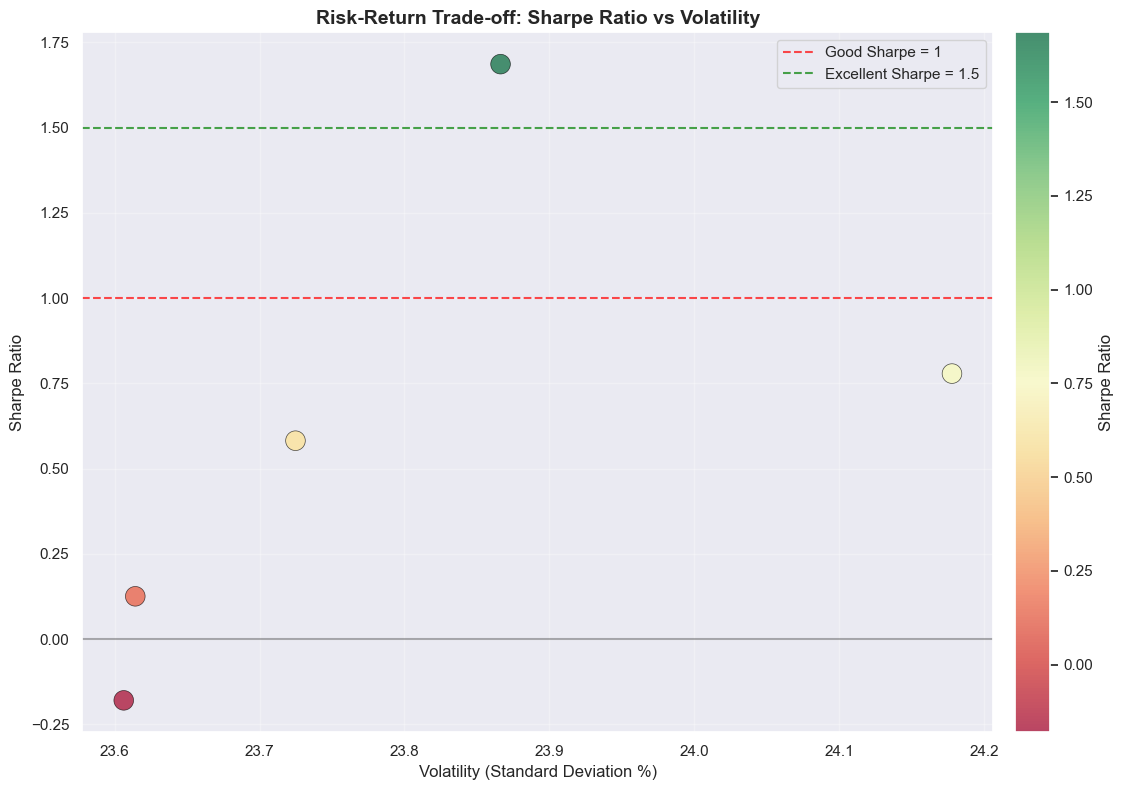

In [11]:
# Calculate Sharpe Ratio
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

sharpe_results = []
for fund in nav_df["amfi_code"].unique():
    fund_data = nav_df[nav_df["amfi_code"] == fund]
    fund_name = fund_data["scheme_name"].iloc[0]
    fund_returns = fund_data["daily_return"].dropna()

    if len(fund_returns) > 1:
        excess_returns = fund_returns - daily_rf
        sharpe = (excess_returns.mean() / fund_returns.std()) * np.sqrt(252)
        volatility = fund_returns.std() * np.sqrt(252) * 100
    else:
        sharpe = 0
        volatility = 0

    sharpe_results.append(
        {
            "amfi_code": fund,
            "scheme_name": fund_name,
            "sharpe_ratio": sharpe,
            "volatility_pct": volatility,
        }
    )

sharpe_df = pd.DataFrame(sharpe_results)
print(f"Sharpe Ratio calculated for {len(sharpe_df)} funds")

### Visualization 2: Sharpe Ratio vs Volatility Scatter Plot
This scatter plot shows the risk-return trade-off. Funds in the top-right quadrant have higher Sharpe ratios (better risk-adjusted returns).

**Key Insights:**
- X-axis: Volatility (risk)
- Y-axis: Sharpe Ratio (return per unit risk)
- Green dashed line: Excellent Sharpe (>1.5)
- Red dashed line: Good Sharpe (>1.0)
- Funds above the red line have positive risk-adjusted returns

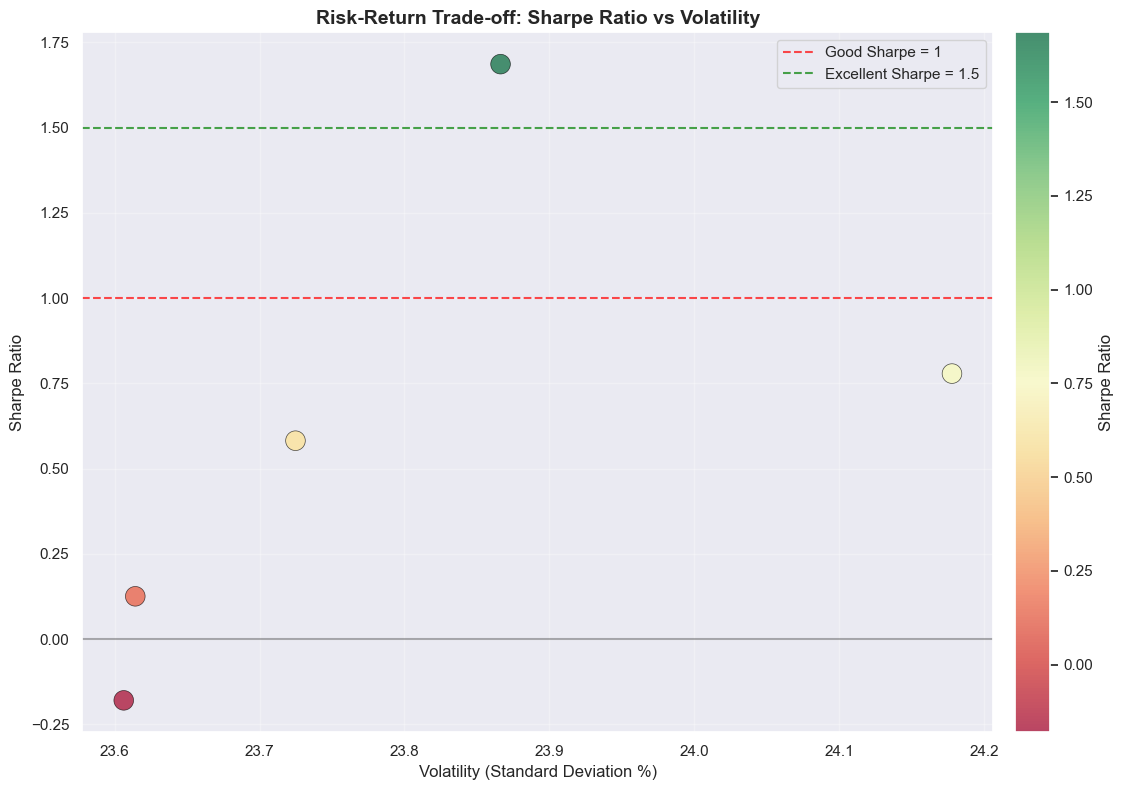

In [16]:
# Visualization: Sharpe Ratio vs Volatility
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    sharpe_df["volatility_pct"],
    sharpe_df["sharpe_ratio"],
    c=sharpe_df["sharpe_ratio"],
    cmap="RdYlGn",
    s=200,
    alpha=0.7,
    edgecolors="black",
    linewidth=0.5,
)
plt.colorbar(scatter, label="Sharpe Ratio", pad=0.02)
plt.xlabel("Volatility (Standard Deviation %)", fontsize=12)
plt.ylabel("Sharpe Ratio", fontsize=12)
plt.title(
    "Risk-Return Trade-off: Sharpe Ratio vs Volatility", fontsize=14, fontweight="bold"
)
plt.axhline(y=1, color="red", linestyle="--", alpha=0.7, label="Good Sharpe = 1")
plt.axhline(
    y=1.5, color="green", linestyle="--", alpha=0.7, label="Excellent Sharpe = 1.5"
)
plt.axhline(y=0, color="black", linestyle="-", alpha=0.3)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)

top_3_sharpe = sharpe_df.nlargest(3, "sharpe_ratio")
for _, row in top_3_sharpe.iterrows():
    plt.annotate(
        row["scheme_name"][:15],
        (row["volatility_pct"] + 0.5, row["sharpe_ratio"]),
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig(REPORTS_DIR / "sharpe_vs_volatility.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualization 3: Sharpe Ratio Ranking Bar Chart
This bar chart ranks the top 10 funds by Sharpe ratio.

**Key Insights:**
- Green bars: Excellent (>1.5)
- Yellow bars: Good (>1.0)
- Red bars: Below benchmark (<1.0)
- Higher bars indicate better risk-adjusted returns

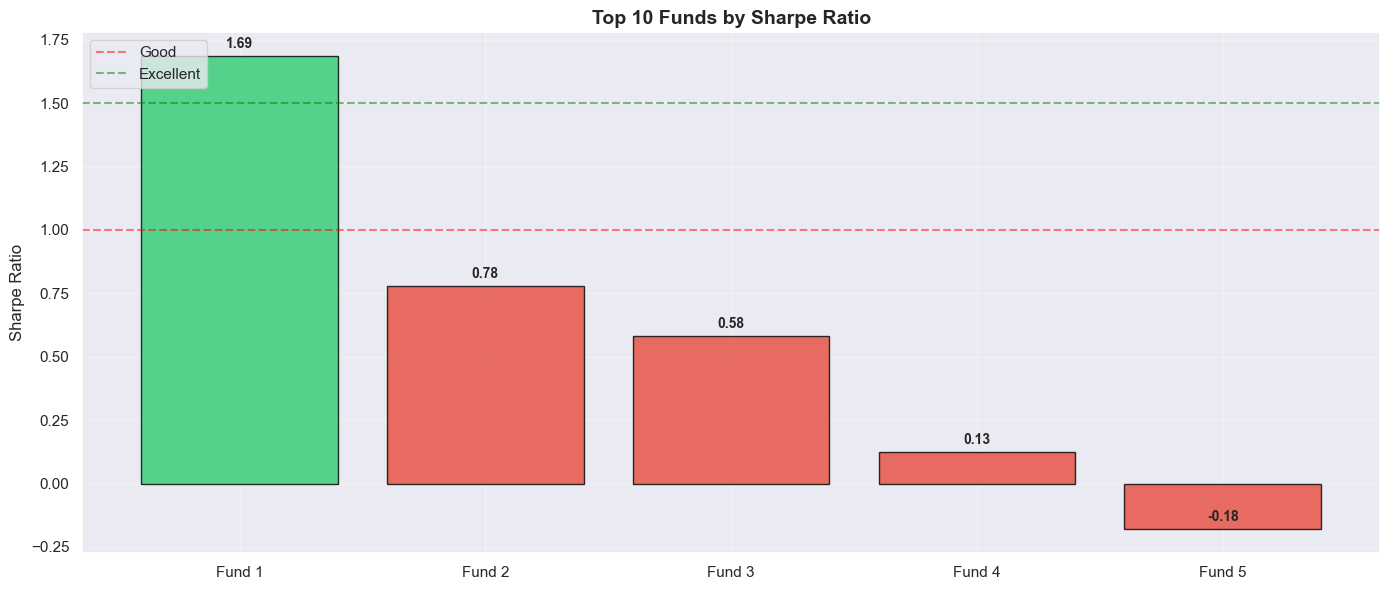

In [17]:
# Sharpe Ratio Ranking Bar Chart
top_10_sharpe = sharpe_df.nlargest(10, "sharpe_ratio")

plt.figure(figsize=(14, 6))
colors = [
    "#2ecc71" if x > 1.5 else "#f1c40f" if x > 1 else "#e74c3c"
    for x in top_10_sharpe["sharpe_ratio"]
]
bars = plt.bar(
    range(len(top_10_sharpe)),
    top_10_sharpe["sharpe_ratio"],
    color=colors,
    edgecolor="black",
    alpha=0.8,
)
plt.xticks(
    range(len(top_10_sharpe)), [f"Fund {i+1}" for i in range(len(top_10_sharpe))]
)
plt.ylabel("Sharpe Ratio", fontsize=12)
plt.title("Top 10 Funds by Sharpe Ratio", fontsize=14, fontweight="bold")
plt.axhline(y=1, color="red", linestyle="--", alpha=0.5, label="Good")
plt.axhline(y=1.5, color="green", linestyle="--", alpha=0.5, label="Excellent")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)

for bar, val in zip(bars, top_10_sharpe["sharpe_ratio"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 0.02,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig(REPORTS_DIR / "sharpe_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Alpha & Beta Calculation
Calculate Alpha and Beta using market regression.
**Method:** OLS regression of fund returns on market returns.

In [21]:
# Calculate Alpha & Beta
returns_wide = nav_df.pivot(index="date", columns="amfi_code", values="daily_return")
market_returns = returns_wide.mean(axis=1)

alpha_beta_results = []
for fund in nav_df["amfi_code"].unique():
    fund_name = nav_df[nav_df["amfi_code"] == fund]["scheme_name"].iloc[0]
    fund_returns = returns_wide[fund].dropna()

    aligned = pd.DataFrame({"fund": fund_returns, "market": market_returns}).dropna()

    if len(aligned) > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            aligned["market"], aligned["fund"]
        )
        beta = slope
        alpha_annualized = intercept * 252 * 100
        r_squared = r_value**2
    else:
        beta = 0
        alpha_annualized = 0
        r_squared = 0

    alpha_beta_results.append(
        {
            "amfi_code": fund,
            "scheme_name": fund_name,
            "alpha": alpha_annualized,
            "beta": beta,
            "r_squared": r_squared,
        }
    )

alpha_beta_df = pd.DataFrame(alpha_beta_results)

### Visualization 4: Alpha vs Beta Scatter Plot
This plot shows fund positioning relative to the market.

**Key Insights:**
- X-axis: Beta (market sensitivity)
- Y-axis: Alpha (annualized excess return %)
- Funds above red line (Alpha=0): Outperformed market
- Funds below red line: Underperformed market
- Color intensity: R-squared (fit quality)

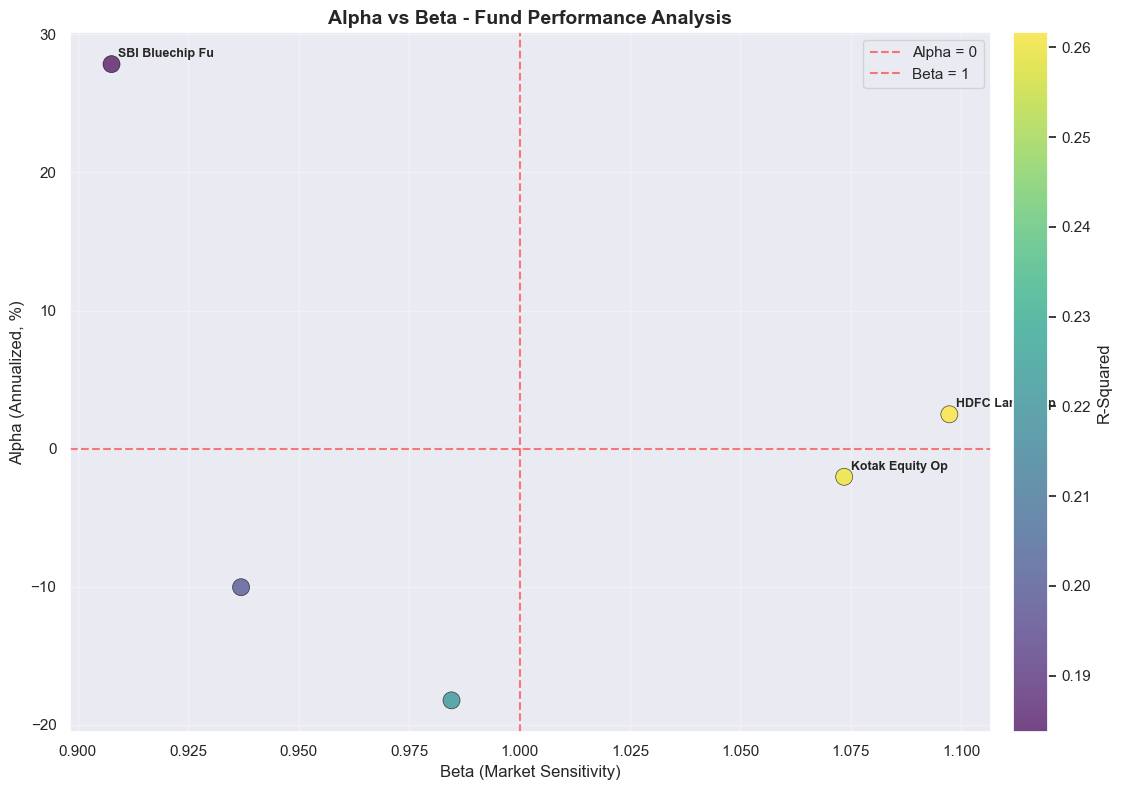

In [22]:
# Visualization: Alpha vs Beta Scatter Plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    alpha_beta_df["beta"],
    alpha_beta_df["alpha"],
    c=alpha_beta_df["r_squared"],
    cmap="viridis",
    s=150,
    alpha=0.7,
    edgecolors="black",
    linewidth=0.5,
)
plt.colorbar(scatter, label="R-Squared", pad=0.02)
plt.axhline(y=0, color="red", linestyle="--", alpha=0.5, label="Alpha = 0")
plt.axvline(x=1, color="red", linestyle="--", alpha=0.5, label="Beta = 1")
plt.xlabel("Beta (Market Sensitivity)", fontsize=12)
plt.ylabel("Alpha (Annualized, %)", fontsize=12)
plt.title("Alpha vs Beta - Fund Performance Analysis", fontsize=14, fontweight="bold")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)

top_alpha = alpha_beta_df.nlargest(3, "alpha")
for _, row in top_alpha.iterrows():
    plt.annotate(
        row["scheme_name"][:15],
        (row["beta"], row["alpha"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig(REPORTS_DIR / "alpha_beta_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Maximum Drawdown Calculation
Calculate maximum drawdown (worst peak-to-trough decline).

In [23]:
# Calculate Maximum Drawdown
drawdown_results = []
for fund in nav_df["amfi_code"].unique():
    fund_data = nav_df[nav_df["amfi_code"] == fund].sort_values("date")
    fund_name = fund_data["scheme_name"].iloc[0]

    cumulative_max = fund_data["nav"].cummax()
    drawdown = (fund_data["nav"] - cumulative_max) / cumulative_max
    max_drawdown = drawdown.min()

    drawdown_results.append(
        {
            "amfi_code": fund,
            "scheme_name": fund_name,
            "max_drawdown": max_drawdown * 100,
        }
    )

drawdown_df = pd.DataFrame(drawdown_results)

### Visualization 5: Maximum Drawdown Bar Chart
This chart shows the worst drawdown for each fund.

**Key Insights:**
- Red bars: Severe drawdown (>30%) - High risk
- Orange bars: Moderate drawdown (20-30%) - Medium risk
- Yellow bars: Low drawdown (<20%) - Low risk
- Lower values (more negative) indicate worse drawdowns

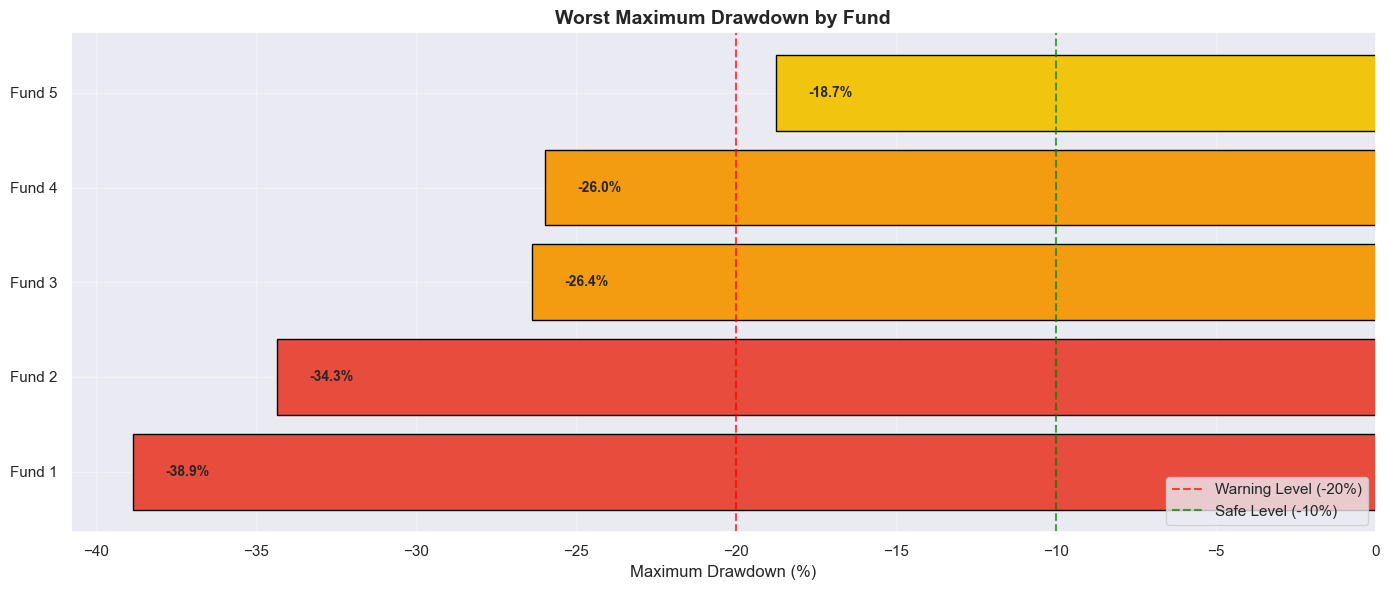

In [24]:
# Visualization: Maximum Drawdown Bar Chart
top_10_dd = drawdown_df.nsmallest(10, "max_drawdown")

plt.figure(figsize=(14, 6))
colors = [
    "#e74c3c" if x < -30 else "#f39c12" if x < -20 else "#f1c40f"
    for x in top_10_dd["max_drawdown"]
]
bars = plt.barh(
    range(len(top_10_dd)), top_10_dd["max_drawdown"], color=colors, edgecolor="black"
)
plt.yticks(range(len(top_10_dd)), [f"Fund {i+1}" for i in range(len(top_10_dd))])
plt.xlabel("Maximum Drawdown (%)", fontsize=12)
plt.title("Worst Maximum Drawdown by Fund", fontsize=14, fontweight="bold")
plt.axvline(x=-20, color="red", linestyle="--", alpha=0.7, label="Warning Level (-20%)")
plt.axvline(x=-10, color="green", linestyle="--", alpha=0.7, label="Safe Level (-10%)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

for bar, val in zip(bars, top_10_dd["max_drawdown"]):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig(REPORTS_DIR / "max_drawdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Fund Scorecard
Create comprehensive fund scorecard (0-100) combining all metrics.

**Weightage:**
- CAGR Rank: 30%
- Sharpe Rank: 30%
- Alpha Rank: 25%
- Drawdown Rank: 15%

In [26]:
# Create Fund Scorecard
scorecard = cagr_df.merge(sharpe_df, on=["amfi_code", "scheme_name"])
scorecard = scorecard.merge(alpha_beta_df, on=["amfi_code", "scheme_name"])
scorecard = scorecard.merge(drawdown_df, on=["amfi_code", "scheme_name"])

# Calculate ranks
scorecard["cagr_rank"] = scorecard["cagr_3y"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)
scorecard["dd_rank"] = scorecard["max_drawdown"].rank(ascending=True)

# Weighted score
weights = {"cagr_rank": 0.30, "sharpe_rank": 0.30, "alpha_rank": 0.25, "dd_rank": 0.15}
scorecard["score"] = sum(
    scorecard[metric] * weight for metric, weight in weights.items()
)
scorecard["score"] = (scorecard["score"] / scorecard["score"].max()) * 100
scorecard = scorecard.sort_values("score", ascending=False)

# Save
scorecard.to_csv(PROCESSED_DIR / "fund_scorecard.csv", index=False)
print(f"Scorecard saved to: {PROCESSED_DIR / 'fund_scorecard.csv'}")

Scorecard saved to: c:\Users\dell\OneDrive\Desktop\Kartikey_Bluestock_MF_Capstone_Submission\Source Code\bluestock_mf_capstone\data\processed\fund_scorecard.csv


### Visualization 6: Fund Scorecard Bar Chart
This chart shows the top 10 funds ranked by the overall scorecard (0-100).

**Key Insights:**
- Higher scores indicate better overall performance
- The score combines returns, risk-adjusted returns, alpha, and drawdown
- The highest score represents the best overall fund

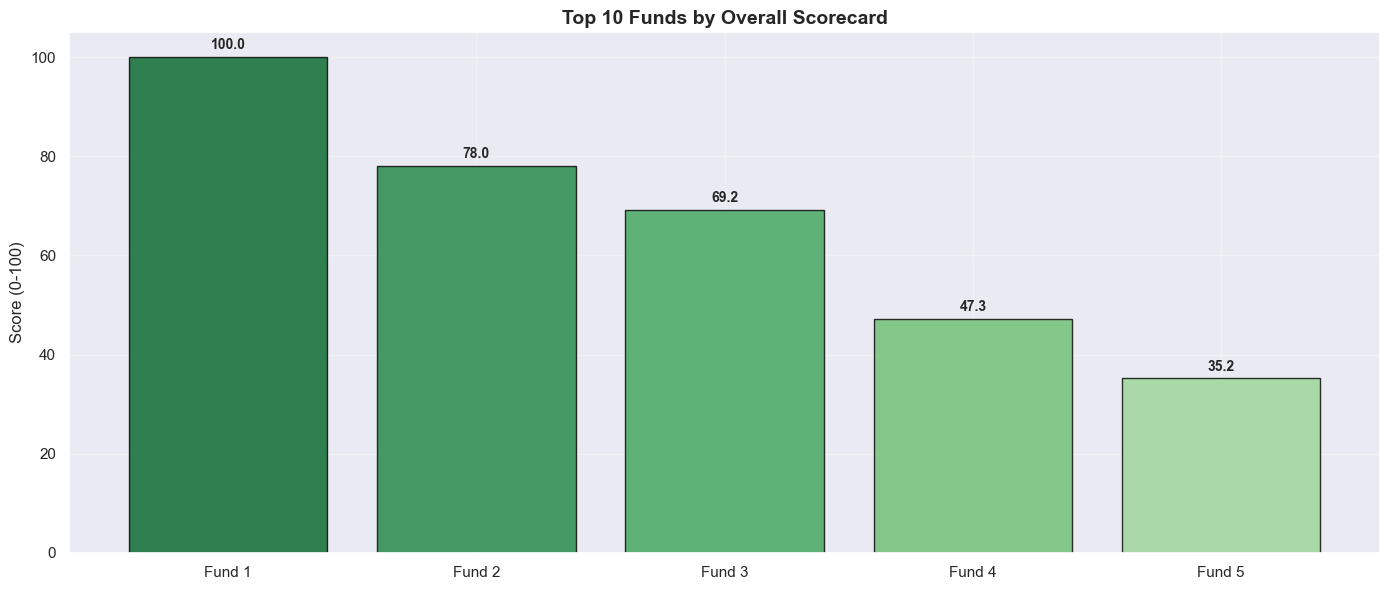

In [27]:
# Visualization: Fund Scorecard Bar Chart
top_10_score = scorecard.head(10)

plt.figure(figsize=(14, 6))
colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(top_10_score)))[::-1]
bars = plt.bar(
    range(len(top_10_score)),
    top_10_score["score"],
    color=colors,
    edgecolor="black",
    alpha=0.8,
)
plt.xticks(range(len(top_10_score)), [f"Fund {i+1}" for i in range(len(top_10_score))])
plt.ylabel("Score (0-100)", fontsize=12)
plt.title("Top 10 Funds by Overall Scorecard", fontsize=14, fontweight="bold")
plt.ylim(0, 105)
plt.grid(True, alpha=0.3)

for bar, val in zip(bars, top_10_score["score"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 1,
        f"{val:.1f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig(REPORTS_DIR / "fund_scorecard.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualization 7: Performance Radar Chart (Top 5 Funds)
This radar chart compares the top 5 funds across multiple performance dimensions.

**Key Insights:**
- Larger area = Better overall performance
- Dimensions: 3Y CAGR, Sharpe Ratio, Alpha, Volatility, Score
- Volatility is inverted (lower is better)
- Each color represents a different fund

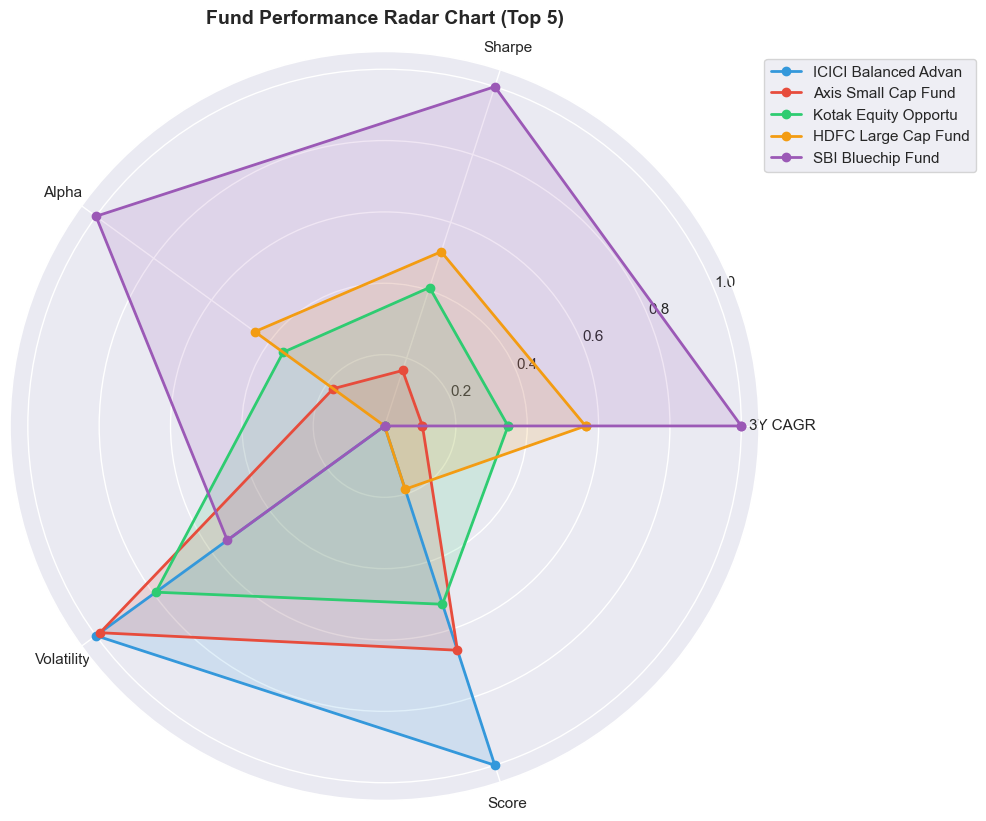

In [28]:
# Radar Chart
top_5_perf = scorecard.head(5)
metrics = ["cagr_3y", "sharpe_ratio", "alpha", "volatility_pct", "score"]

# Normalize data
normalized = top_5_perf[metrics].copy()
for col in metrics:
    if col == "volatility_pct":
        normalized[col] = 1 - (normalized[col] - normalized[col].min()) / (
            normalized[col].max() - normalized[col].min()
        )
    else:
        normalized[col] = (normalized[col] - normalized[col].min()) / (
            normalized[col].max() - normalized[col].min()
        )

angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection="polar"))
colors = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#9b59b6"]

for i, (idx, row) in enumerate(top_5_perf.iterrows()):
    values = normalized.loc[idx, metrics].values.tolist()
    values += values[:1]
    ax.plot(
        angles,
        values,
        "o-",
        linewidth=2,
        label=row["scheme_name"][:20],
        color=colors[i],
    )
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["3Y CAGR", "Sharpe", "Alpha", "Volatility", "Score"], fontsize=11)
ax.set_title(
    "Fund Performance Radar Chart (Top 5)", fontsize=14, fontweight="bold", pad=20
)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.savefig(REPORTS_DIR / "performance_radar.png", dpi=150, bbox_inches="tight")
plt.show()

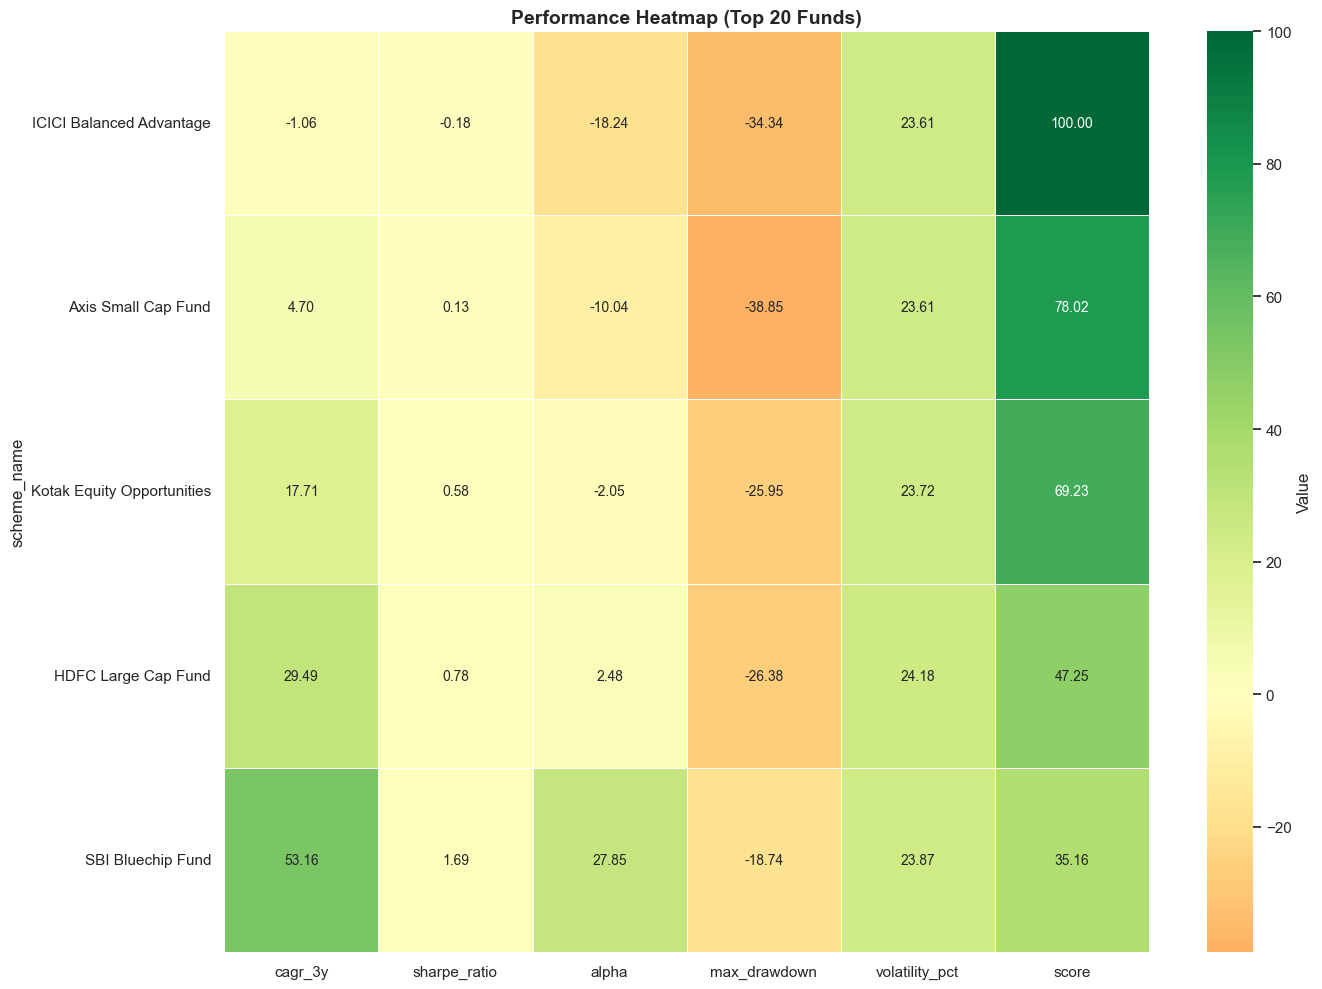

In [29]:
# Performance Heatmap
heatmap_data = scorecard.head(20)[
    [
        "scheme_name",
        "cagr_3y",
        "sharpe_ratio",
        "alpha",
        "max_drawdown",
        "volatility_pct",
        "score",
    ]
]
heatmap_data = heatmap_data.set_index("scheme_name")

plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Value"},
)
plt.title("Performance Heatmap (Top 20 Funds)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "performance_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualization 9: Performance Metrics Distribution
This set of histograms shows the distribution of key performance metrics across all funds.

**Key Insights:**
- Each histogram shows how funds are distributed for each metric
- Red dashed line shows the mean value
- Helps identify normal ranges for each metric
- Identifies outliers and trends

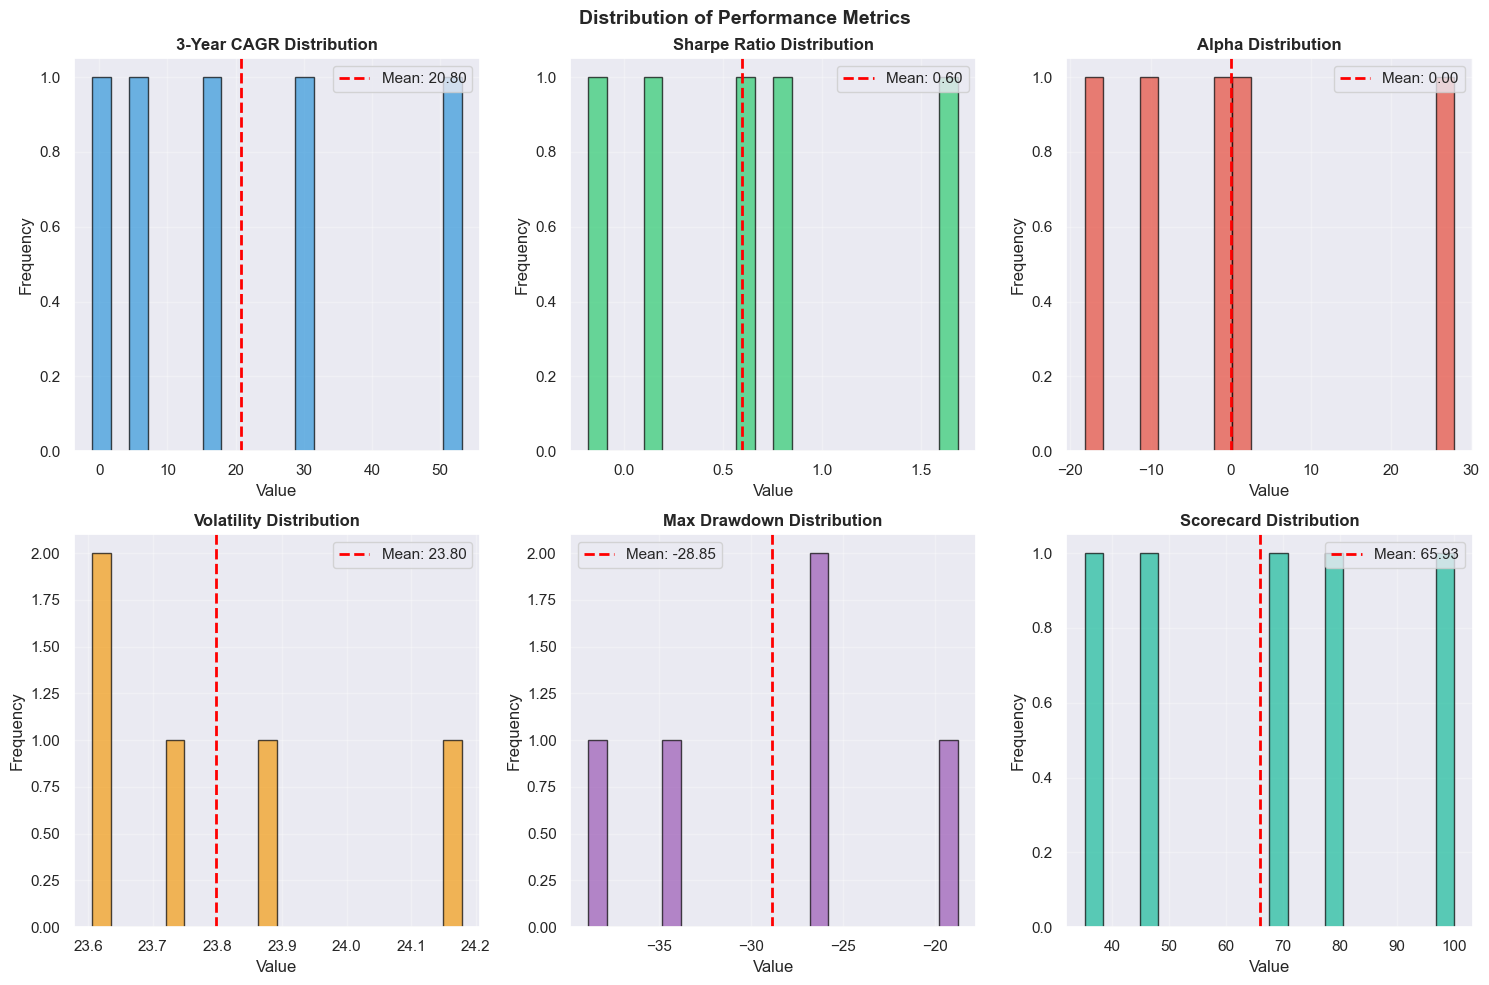

In [30]:
# Distribution of Performance Metrics
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

metrics_dist = [
    "cagr_3y",
    "sharpe_ratio",
    "alpha",
    "volatility_pct",
    "max_drawdown",
    "score",
]
titles = [
    "3-Year CAGR Distribution",
    "Sharpe Ratio Distribution",
    "Alpha Distribution",
    "Volatility Distribution",
    "Max Drawdown Distribution",
    "Scorecard Distribution",
]
colors_dist = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12", "#9b59b6", "#1abc9c"]

for i, (metric, title, color) in enumerate(zip(metrics_dist, titles, colors_dist)):
    row, col = i // 3, i % 3
    ax = axes[row, col]
    ax.hist(scorecard[metric], bins=20, color=color, edgecolor="black", alpha=0.7)
    ax.axvline(
        x=scorecard[metric].mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {scorecard[metric].mean():.2f}",
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Distribution of Performance Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "performance_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualization 10: Performance vs Risk Quadrant
This quadrant analysis shows funds categorized by risk (volatility) and return (CAGR).

**Key Insights:**
- Top-Left: Low Risk, High Return (IDEAL)
- Top-Right: High Risk, High Return
- Bottom-Left: Low Risk, Low Return
- Bottom-Right: High Risk, Low Return (AVOID)
- Color: Scorecard score
- Red lines: Mean values

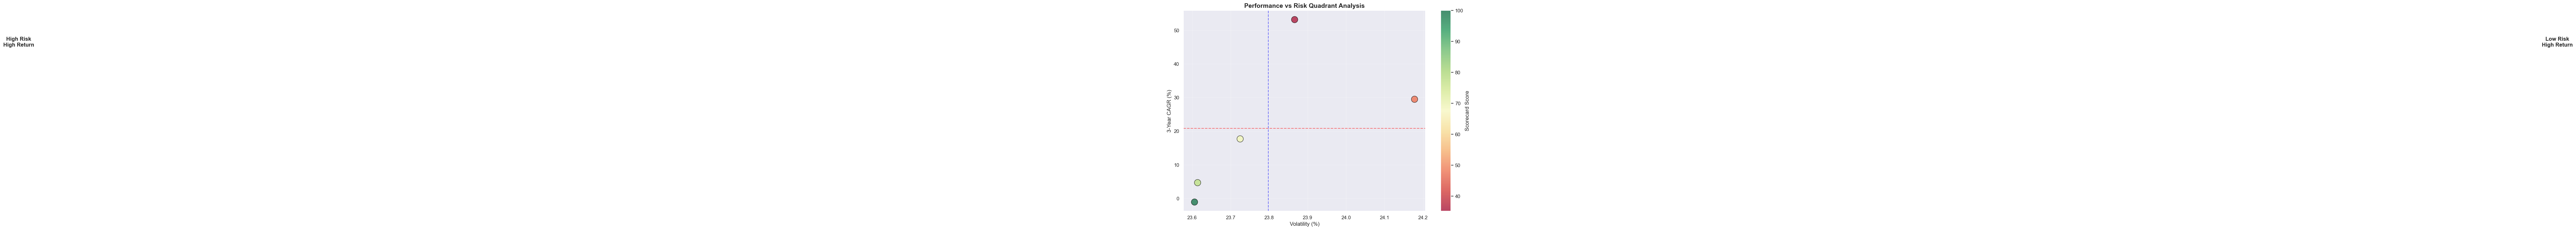

In [31]:
# Performance vs Risk Quadrant
plt.figure(figsize=(12, 8))
colors = scorecard["score"]
scatter = plt.scatter(
    scorecard["volatility_pct"],
    scorecard["cagr_3y"],
    c=colors,
    cmap="RdYlGn",
    s=200,
    alpha=0.7,
    edgecolors="black",
)
plt.colorbar(scatter, label="Scorecard Score")

plt.axhline(y=scorecard["cagr_3y"].mean(), color="red", linestyle="--", alpha=0.5)
plt.axvline(
    x=scorecard["volatility_pct"].mean(), color="blue", linestyle="--", alpha=0.5
)

plt.text(
    scorecard["volatility_pct"].max() * 0.85,
    scorecard["cagr_3y"].max() * 0.85,
    "High Risk\nHigh Return",
    fontsize=12,
    fontweight="bold",
    ha="center",
)
plt.text(
    scorecard["volatility_pct"].min() * 1.15,
    scorecard["cagr_3y"].max() * 0.85,
    "Low Risk\nHigh Return",
    fontsize=12,
    fontweight="bold",
    ha="center",
)

plt.xlabel("Volatility (%)", fontsize=12)
plt.ylabel("3-Year CAGR (%)", fontsize=12)
plt.title("Performance vs Risk Quadrant Analysis", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "performance_risk_quadrant.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualization 11: Performance Summary Table
This table provides a comprehensive summary of the top 10 funds with all key metrics.

In [35]:
# Performance Summary Table
summary_table = scorecard.head(10)[
    [
        "scheme_name",
        "cagr_3y",
        "sharpe_ratio",
        "alpha",
        "max_drawdown",
        "volatility_pct",
        "score",
    ]
]
# set index dynamically to match number of rows
summary_table.index = range(1, len(summary_table) + 1)
summary_table.columns = [
    "Fund Name",
    "3Y CAGR%",
    "Sharpe",
    "Alpha%",
    "Max DD%",
    "Volatility%",
    "Score",
]

print("\n" + "=" * 80)
print("TOP FUNDS PERFORMANCE SUMMARY")
print("=" * 80)
print(summary_table.to_string())
print("=" * 80)

# Save to CSV
summary_table.to_csv(REPORTS_DIR / "performance_summary.csv")
print(f"\n✅ Performance summary saved to: {REPORTS_DIR / 'performance_summary.csv'}")


TOP FUNDS PERFORMANCE SUMMARY
                    Fund Name   3Y CAGR%    Sharpe     Alpha%    Max DD%  Volatility%       Score
1    ICICI Balanced Advantage  -1.060148 -0.179835 -18.239626 -34.343060    23.606267  100.000000
2         Axis Small Cap Fund   4.698907  0.125302 -10.043589 -38.850320    23.614237   78.021978
3  Kotak Equity Opportunities  17.707349  0.581661  -2.045189 -25.953588    23.724801   69.230769
4         HDFC Large Cap Fund  29.488377  0.778494   2.481715 -26.375514    24.177928   47.252747
5           SBI Bluechip Fund  53.164465  1.685999  27.846689 -18.736022    23.866341   35.164835

✅ Performance summary saved to: c:\Users\dell\OneDrive\Desktop\Kartikey_Bluestock_MF_Capstone_Submission\Source Code\bluestock_mf_capstone\reports\eda_plots\performance_summary.csv


## Performance Analytics Complete

✅ All performance metrics calculated and visualized.

**Generated Files:**
- `cagr_results.csv`
- `sharpe_ratios.csv`
- `alpha_beta.csv`
- `max_drawdown.csv`
- `fund_scorecard.csv`
- `performance_summary.csv`

**Visualizations (11 Charts):**
1. ✅ CAGR Comparison Bar Chart
2. ✅ Sharpe Ratio vs Volatility Scatter Plot
3. ✅ Sharpe Ratio Ranking Bar Chart
4. ✅ Alpha vs Beta Scatter Plot
5. ✅ Maximum Drawdown Bar Chart
6. ✅ Fund Scorecard Bar Chart
7. ✅ Performance Radar Chart
8. ✅ Performance Heatmap
9. ✅ Performance Metrics Distribution
10. ✅ Performance vs Risk Quadrant
11. ✅ Performance Summary Table

**Next Steps:** Proceed to Notebook 5: Advanced Analytics